<div style="background:linear-gradient(135deg, #1a1a30 0%, #2a2a3e 100%); border:1px solid #6C63FF; border-radius:10px; padding:28px 30px; margin:10px 0 20px 0; font-family:'Segoe UI', sans-serif; text-align:center;">
  <h1 style="margin:0; font-size:26px; color:#e0e0f0; font-weight:800; letter-spacing:0.5px;">Pipeline de Nettoyage du Dataset</h1>
  <p style="margin:8px 0 0 0; font-size:14px; color:#b0b0cc;">Chargement, exploration, nettoyage et export des donnees malware / goodware.</p>
</div>


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv("dataset.csv")
print("nombre de lignes : ",df.shape[0])
print("nombre de colonnes : ",df.shape[1])
print("description : \n")
print(df.iloc[:,:6].describe())
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
print('\n')
print("head : \n")
print(df['Label'])

nombre de lignes :  806
nombre de colonnes :  65
description : 

        CopyFileA   CopyFileW  CreateDirectoryW   DeleteFileW  DeviceIoControl
count  806.000000  806.000000        806.000000    806.000000       806.000000
mean     0.291563    0.430521         35.688586     94.099256       139.179901
std      3.154506    3.777937        411.095756   1229.299984      3526.562238
min      0.000000    0.000000          0.000000      0.000000         0.000000
25%      0.000000    0.000000          0.000000      0.000000         0.000000
50%      0.000000    0.000000          0.000000      0.000000         0.000000
75%      0.000000    0.000000          8.000000      2.000000         3.000000
max     68.000000   60.000000      11463.000000  20001.000000     99984.000000


head : 

0      0
1      0
2      0
3      0
4      0
      ..
801    1
802    1
803    1
804    1
805    1
Name: Label, Length: 806, dtype: int64


<div style="background:#2a2a3e; border-left:4px solid #FF6584; border-radius:5px; padding:13px 18px; margin:12px 0 8px 0; font-family:'Segoe UI', sans-serif;">
  <h3 style="margin:0; font-size:16px; color:#e0e0f0; font-weight:600;">Exploration du dataset brut</h3>
  <p style="margin:5px 0 0 0; font-size:12.5px; color:#aaaacc;">Distribution des classes et histogrammes des features avant tout nettoyage.</p>
</div>


Lignes   : 806
Colonnes : 65



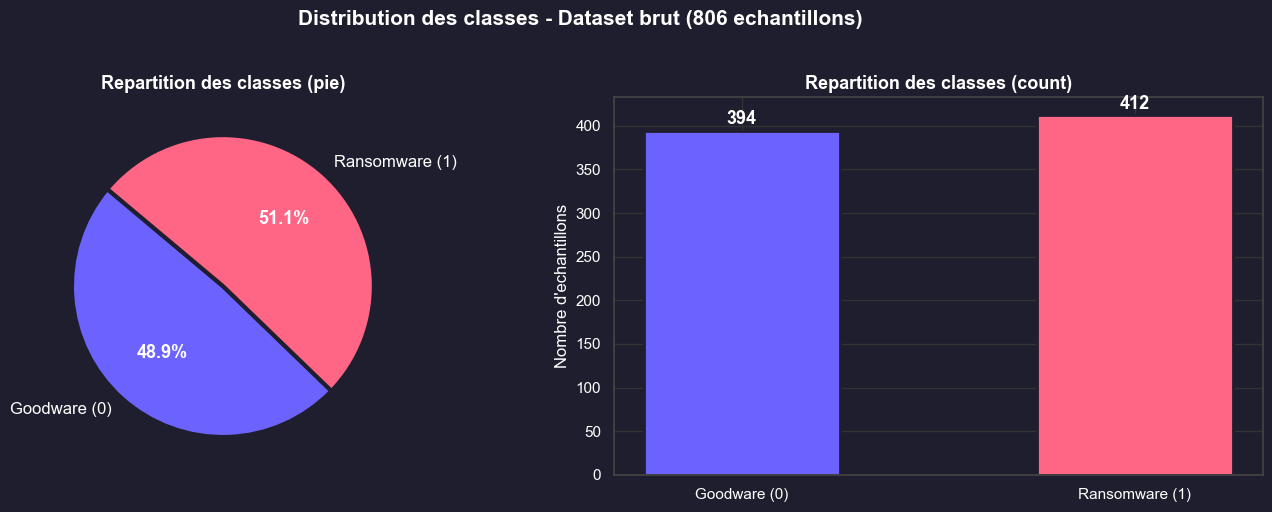

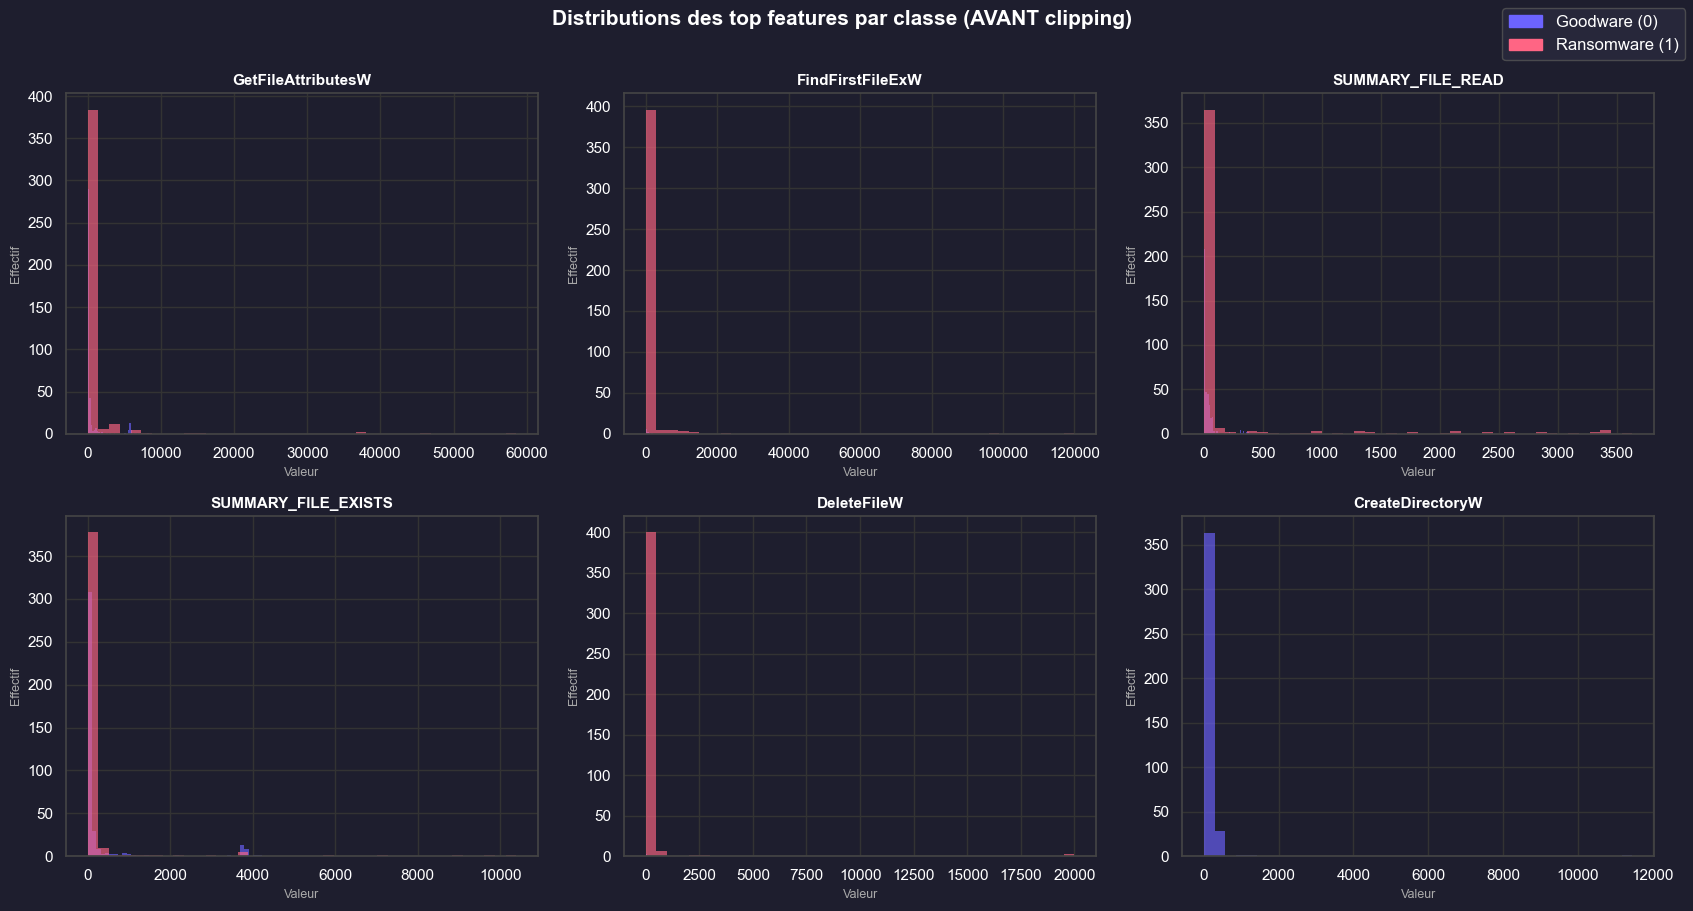

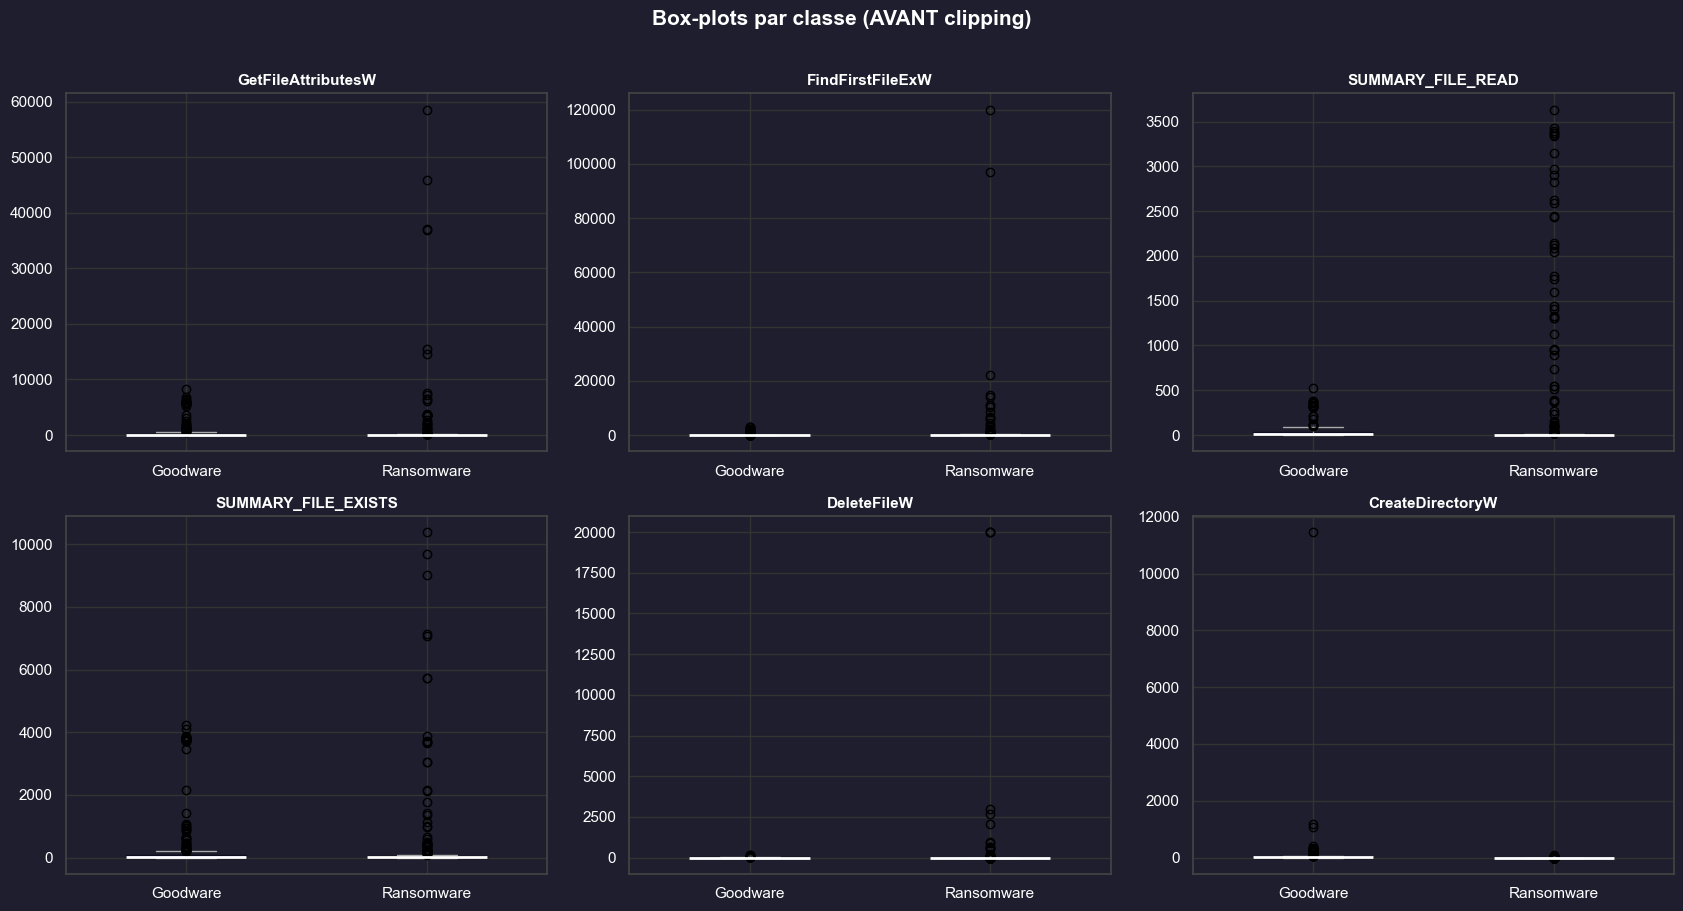

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ------- style global (fond sombre, palette violette/rose) ------
sns.set_theme(style='darkgrid')
DARK_BG   = '#1e1e2e'
CLR_GOOD  = '#6C63FF'   # goodware
CLR_RANSOM = '#FF6584'  # ransomware
plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': DARK_BG,
    'text.color': 'white',       'axes.labelcolor': 'white',
    'xtick.color': 'white',       'ytick.color': 'white',
    'axes.titlecolor': 'white',   'axes.edgecolor': '#444',
    'grid.color': '#333',
})
palette   = [CLR_GOOD, CLR_RANSOM]
handles   = [mpatches.Patch(color=CLR_GOOD,   label='Goodware (0)'),
             mpatches.Patch(color=CLR_RANSOM, label='Ransomware (1)')]

# ================================================================
# 1.A  Forme du dataset
# ================================================================
print(f'Lignes   : {df.shape[0]}')
print(f'Colonnes : {df.shape[1]}')
print()

# ================================================================
# 1.B  Distribution des classes  (pie + bar)
# ================================================================
counts = df['Label'].value_counts().sort_index()
labels_names = ['Goodware (0)', 'Ransomware (1)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)

# pie
wp, tp, ap = axes[0].pie(
    counts, labels=labels_names, colors=palette, autopct='%1.1f%%',
    startangle=140, textprops={'color':'white','fontsize':12},
    wedgeprops={'edgecolor': DARK_BG, 'linewidth':3}
)
for at in ap:
    at.set_fontsize(13); at.set_fontweight('bold')
axes[0].set_title('Repartition des classes (pie)', fontsize=13, fontweight='bold')

# bar
bars = axes[1].bar(labels_names, counts.values,
                   color=palette, edgecolor=DARK_BG, linewidth=2, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', color='white',
                 fontsize=13, fontweight='bold')
axes[1].set_title('Repartition des classes (count)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nombre d\'echantillons')
axes[1].set_facecolor(DARK_BG)
for sp in axes[1].spines.values(): sp.set_edgecolor('#444')

plt.suptitle('Distribution des classes - Dataset brut (806 echantillons)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ================================================================
# 1.C  Histogrammes des top features (avant clipping)
# ================================================================
top_feats = ['GetFileAttributesW', 'FindFirstFileExW', 'SUMMARY_FILE_READ',
             'SUMMARY_FILE_EXISTS', 'DeleteFileW', 'CreateDirectoryW']

fig2, axes2 = plt.subplots(2, 3, figsize=(17, 9))
fig2.patch.set_facecolor(DARK_BG)
axes2 = axes2.flatten()

for ax, feat in zip(axes2, top_feats):
    for lbl, color in zip([0, 1], palette):
        ax.hist(df[df['Label'] == lbl][feat], bins=40,
                color=color, alpha=0.65, edgecolor='none')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_facecolor(DARK_BG)
    ax.tick_params(colors='white')
    ax.set_xlabel('Valeur', color='#aaa', fontsize=9)
    ax.set_ylabel('Effectif', color='#aaa', fontsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor('#444')

fig2.legend(handles=handles, loc='upper right', fontsize=12,
            facecolor='#2a2a3e', edgecolor='#555', labelcolor='white')
plt.suptitle('Distributions des top features par classe (AVANT clipping)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ================================================================
# 1.D  Box-plots par classe (top 6 features)
# ================================================================
import warnings
warnings.filterwarnings('ignore')

fig3, axes3 = plt.subplots(2, 3, figsize=(17, 9))
fig3.patch.set_facecolor(DARK_BG)
axes3 = axes3.flatten()

for ax, feat in zip(axes3, top_feats):
    data_by_class = [df[df['Label'] == lbl][feat].dropna() for lbl in [0, 1]]
    bp = ax.boxplot(data_by_class, patch_artist=True, widths=0.5,
                    medianprops={'color':'white','linewidth':2})
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for wh in bp['whiskers'] + bp['caps'] + bp['fliers']:
        wh.set_color('#aaa')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_facecolor(DARK_BG)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Goodware', 'Ransomware'], color='white')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.suptitle('Box-plots par classe (AVANT clipping)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<div style="background:#2a2a3e; border-left:5px solid #6C63FF; border-radius:6px; padding:18px 22px; margin:16px 0 10px 0; font-family:'Segoe UI', sans-serif;">
  <span style="display:inline-block; background:#6C63FF; color:white; font-size:11px; font-weight:700; padding:2px 9px; border-radius:20px; letter-spacing:1px; margin-bottom:8px;">ETAPE 1</span>
  <h2 style="margin:0; font-size:20px; color:#e0e0f0; font-weight:700; letter-spacing:0.3px;">Clipping au 99e percentile</h2>
  <p style="margin:6px 0 0 0; font-size:13px; color:#b0b0cc; font-weight:400;">Ecrêtage des valeurs aberrantes : chaque feature est plafonnee a son 99e percentile.</p>
</div>


In [17]:
for col in df.columns[1:]:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)
    print(p99)

2.0
10.900000000000091
307.0
625.6000000000004
230.85000000000014
8325.800000000085
1559.0
7229.400000000015
17.0
100.80000000000018
1299.5500000000104
3830.9000000000074
3652.050000000083
16.0
16.0
27.0
28.90000000000009
22.850000000000136
1717.0
213.75000000000023
2338.750000000032
1716.0
1727.0
31.800000000000182
18.0
32.0
12.950000000000045
6.0
2376.8500000000067
8405.95000000002
2930.2000000000144
66.0
4356.650000000005
923.4500000000096
13252.30000000008
4734.150000000009
35111.35000000004
1970.1500000000026
18068.800000000076
4.0
4.0
66.75000000000023
1870.1000000000054
3408.300000000009
18.0
24337.750000000007
6866.400000000001
1869.1000000000054
300.0
4820.900000000025
8.950000000000045
25.950000000000045
1746.95
531.1000000000154
4092.5000000000095
1671.0500000000145
2068.350000000002
4230.950000000018
2963.900000000003
188.0
3472.850000000015
1.0
0.0
4.0


<div style="background:#2a2a3e; border-left:4px solid #FF6584; border-radius:5px; padding:13px 18px; margin:12px 0 8px 0; font-family:'Segoe UI', sans-serif;">
  <h3 style="margin:0; font-size:16px; color:#e0e0f0; font-weight:600;">Distributions apres clipping</h3>
  <p style="margin:5px 0 0 0; font-size:12.5px; color:#aaaacc;">Les memes features qu'avant. Notez la reduction de l'echelle des valeurs.</p>
</div>


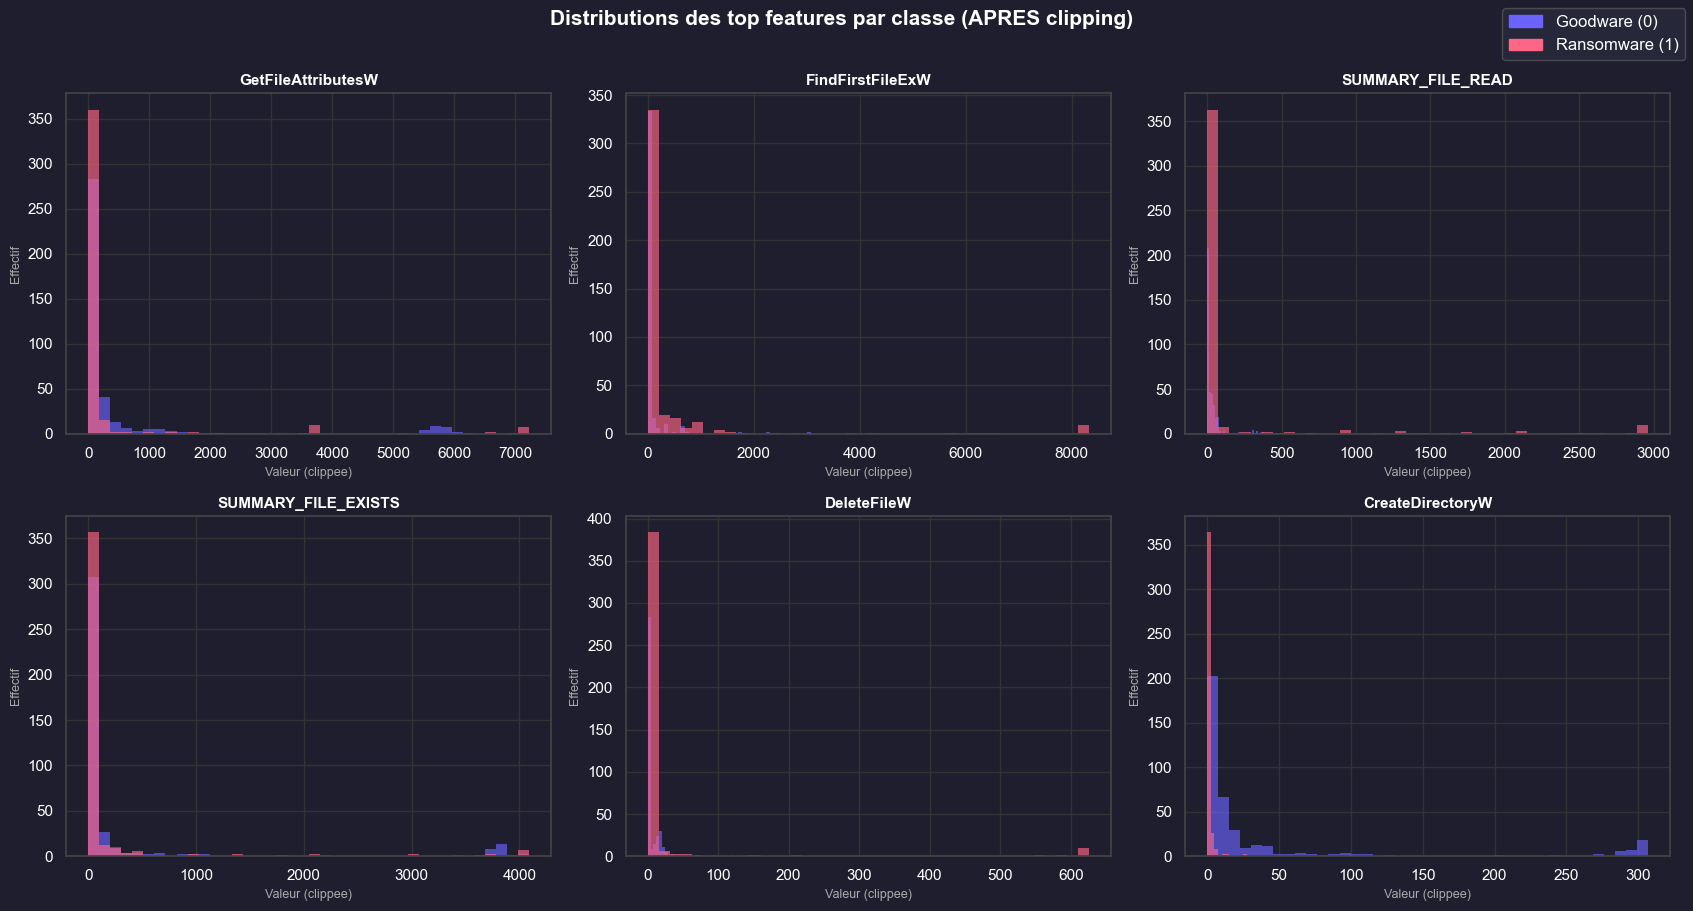

In [18]:
fig4, axes4 = plt.subplots(2, 3, figsize=(17, 9))
fig4.patch.set_facecolor(DARK_BG)
axes4 = axes4.flatten()

for ax, feat in zip(axes4, top_feats):
    for lbl, color in zip([0, 1], palette):
        ax.hist(df[df['Label'] == lbl][feat], bins=40,
                color=color, alpha=0.65, edgecolor='none')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_facecolor(DARK_BG)
    ax.tick_params(colors='white')
    ax.set_xlabel('Valeur (clippee)', color='#aaa', fontsize=9)
    ax.set_ylabel('Effectif', color='#aaa', fontsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor('#444')

fig4.legend(handles=handles, loc='upper right', fontsize=12,
            facecolor='#2a2a3e', edgecolor='#555', labelcolor='white')
plt.suptitle('Distributions des top features par classe (APRES clipping)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<div style="background:#2a2a3e; border-left:5px solid #6C63FF; border-radius:6px; padding:18px 22px; margin:16px 0 10px 0; font-family:'Segoe UI', sans-serif;">
  <span style="display:inline-block; background:#6C63FF; color:white; font-size:11px; font-weight:700; padding:2px 9px; border-radius:20px; letter-spacing:1px; margin-bottom:8px;">ETAPE 2</span>
  <h2 style="margin:0; font-size:20px; color:#e0e0f0; font-weight:700; letter-spacing:0.3px;">Valeurs manquantes et doublons</h2>
  <p style="margin:6px 0 0 0; font-size:13px; color:#b0b0cc; font-weight:400;">Verification des NaN et suppression des lignes dupliquees.</p>
</div>


In [19]:
print(df.isna().any())
print("il n'ya pas des valeurs manquees")
df_nv = df.drop_duplicates()
print("le nombre des lignes duplique est : ",df.shape[0]-df_nv.shape[0])

Label                        False
CopyFileA                    False
CopyFileW                    False
CreateDirectoryW             False
DeleteFileW                  False
                             ...  
SUMMARY_FILE_RECREATED       False
SUMMARY_FILE_WRITTEN         False
URLDownloadToFileW           False
FindFirstFileExA             False
NtQueryFullAttributesFile    False
Length: 65, dtype: bool
il n'ya pas des valeurs manquees
le nombre des lignes duplique est :  218


In [20]:
X = df_nv.drop('Label', axis=1)
y = df_nv['Label']
print(y.head())

0    0
1    0
3    0
4    0
5    0
Name: Label, dtype: int64


<div style="background:#2a2a3e; border-left:5px solid #6C63FF; border-radius:6px; padding:18px 22px; margin:16px 0 10px 0; font-family:'Segoe UI', sans-serif;">
  <span style="display:inline-block; background:#6C63FF; color:white; font-size:11px; font-weight:700; padding:2px 9px; border-radius:20px; letter-spacing:1px; margin-bottom:8px;">ETAPE 3</span>
  <h2 style="margin:0; font-size:20px; color:#e0e0f0; font-weight:700; letter-spacing:0.3px;">Suppression variance nulle / colonnes quasi-nulles</h2>
  <p style="margin:6px 0 0 0; font-size:13px; color:#b0b0cc; font-weight:400;">Colonnes a ecart-type nul ou a plus de 98 % de zeros supprimees.</p>
</div>


In [21]:
for col in df_nv.columns:
    if df_nv[col].std() == 0:
        print("la colonne a supprimee c'est", col)
        df_nv = df_nv.drop(col, axis=1)
    else:
        if (df_nv[col]==0).sum() / len(df_nv[col]) >= 0.98:
            print("la colonne a supprimee c'est", col)
            df_nv = df_nv.drop(col, axis=1)
df=df_nv   
print(df.shape[1])   

la colonne a supprimee c'est FindFirstFileExA
64


<div style="background:#2a2a3e; border-left:5px solid #6C63FF; border-radius:6px; padding:18px 22px; margin:16px 0 10px 0; font-family:'Segoe UI', sans-serif;">
  <span style="display:inline-block; background:#6C63FF; color:white; font-size:11px; font-weight:700; padding:2px 9px; border-radius:20px; letter-spacing:1px; margin-bottom:8px;">ETAPE 4</span>
  <h2 style="margin:0; font-size:20px; color:#e0e0f0; font-weight:700; letter-spacing:0.3px;">Suppression des colonnes tres correlees</h2>
  <p style="margin:6px 0 0 0; font-size:13px; color:#b0b0cc; font-weight:400;">Toute feature dont la correlation absolue de Pearson depasse 0.9 avec une autre est retiree.</p>
</div>


<div style="background:#2a2a3e; border-left:4px solid #FF6584; border-radius:5px; padding:13px 18px; margin:12px 0 8px 0; font-family:'Segoe UI', sans-serif;">
  <h3 style="margin:0; font-size:16px; color:#e0e0f0; font-weight:600;">Heatmap de correlation — AVANT suppression</h3>
  <p style="margin:5px 0 0 0; font-size:12.5px; color:#aaaacc;">Les paires qui depassent le seuil de 0.9 sont visibles ci-dessous.</p>
</div>


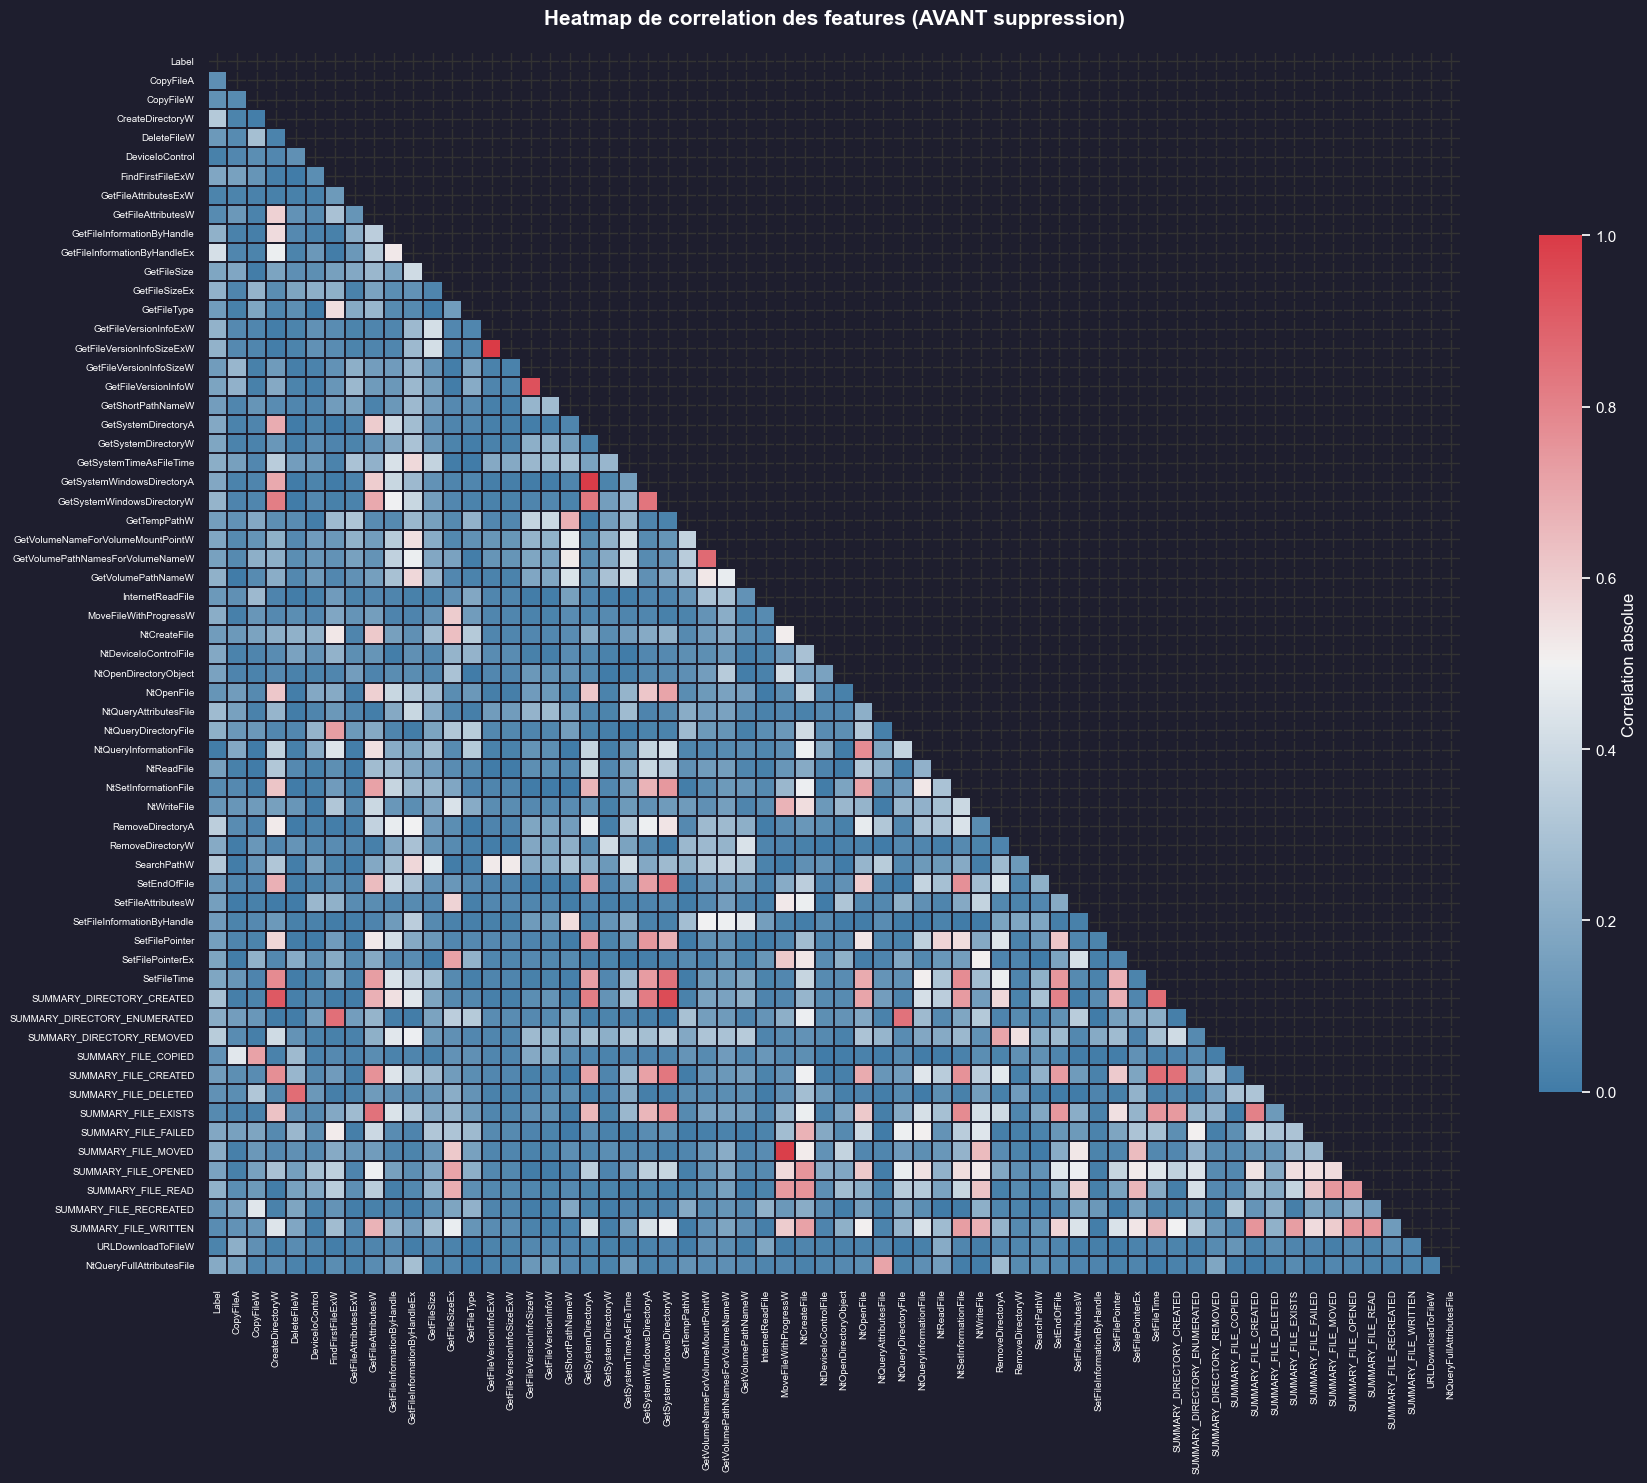

In [22]:
corr_before = df.corr().abs()
import numpy as np

fig5, ax5 = plt.subplots(figsize=(18, 15))
fig5.patch.set_facecolor(DARK_BG)
ax5.set_facecolor(DARK_BG)

mask = np.triu(np.ones_like(corr_before, dtype=bool))
cmap_div = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(
    corr_before, mask=mask, cmap=cmap_div, vmax=1.0, vmin=0,
    center=0.5, annot=False, linewidths=0.3, linecolor=DARK_BG,
    ax=ax5, cbar_kws={'shrink': 0.7, 'label': 'Correlation absolue'}
)
ax5.set_title('Heatmap de correlation des features (AVANT suppression)',
              fontsize=15, fontweight='bold', pad=20)
ax5.tick_params(colors='white', labelsize=7)
ax5.figure.axes[-1].tick_params(colors='white')
ax5.figure.axes[-1].yaxis.label.set_color('white')
plt.tight_layout()
plt.show()


In [23]:
import numpy as np

corr_matrix = df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.9
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

df = df.drop(columns=to_drop)

print("Colonnes supprimees :", to_drop)

Colonnes supprimees : ['GetFileVersionInfoSizeExW', 'GetFileVersionInfoW', 'GetSystemWindowsDirectoryA', 'SUMMARY_DIRECTORY_CREATED', 'SUMMARY_FILE_MOVED']


In [24]:
df['Label'].value_counts()
df.shape

(588, 59)

<div style="background:#2a2a3e; border-left:4px solid #FF6584; border-radius:5px; padding:13px 18px; margin:12px 0 8px 0; font-family:'Segoe UI', sans-serif;">
  <h3 style="margin:0; font-size:16px; color:#e0e0f0; font-weight:600;">Resume avant / apres nettoyage</h3>
  <p style="margin:5px 0 0 0; font-size:12.5px; color:#aaaacc;">Evolution du nombre de lignes et de colonnes a chaque etape du pipeline.</p>
</div>


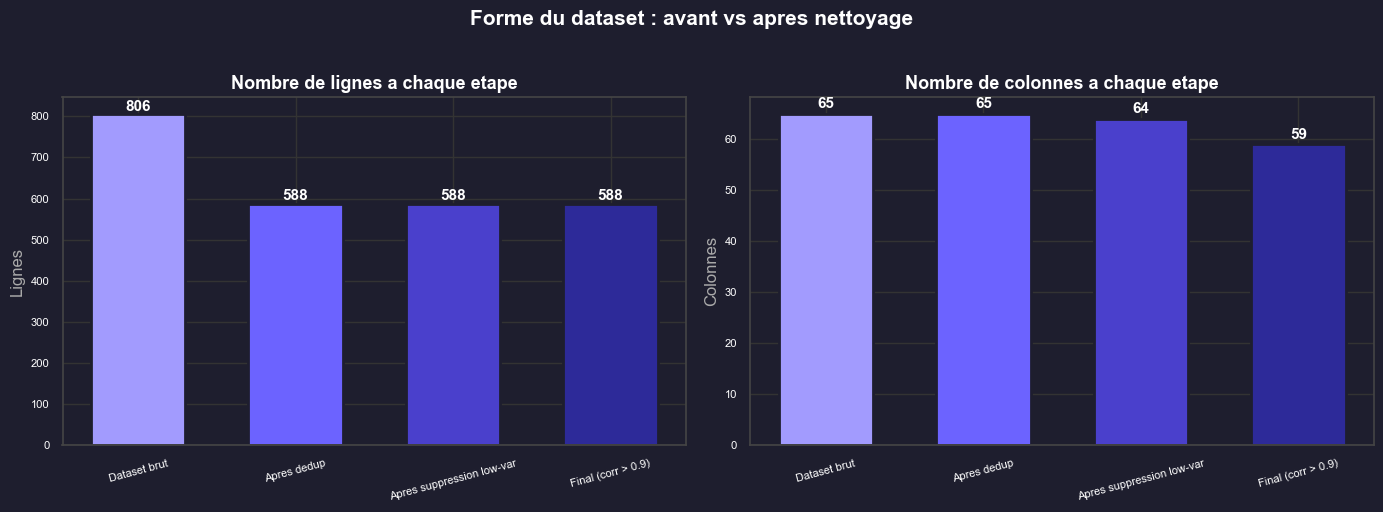

                    Etape  Lignes  Colonnes
             Dataset brut     806        65
              Apres dedup     588        65
Apres suppression low-var     588        64
       Final (corr > 0.9)     588        59


In [25]:
stages     = ['Dataset brut', 'Apres dedup', 'Apres suppression low-var', 'Final (corr > 0.9)']
row_counts = [806, df_nv.shape[0], df_nv.shape[0], df.shape[0]]
col_counts = [65,  65,             64,              df.shape[1]]
grad       = ['#a29bfe', '#6C63FF', '#4a40cc', '#2d2a99']

fig6, axes6 = plt.subplots(1, 2, figsize=(14, 5))
fig6.patch.set_facecolor(DARK_BG)

for ax, vals, title, ylabel in zip(
    axes6,
    [row_counts, col_counts],
    ['Nombre de lignes a chaque etape', 'Nombre de colonnes a chaque etape'],
    ['Lignes', 'Colonnes']
):
    bars = ax.bar(stages, vals, color=grad, edgecolor=DARK_BG, linewidth=2, width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', va='bottom', color='white',
                fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_facecolor(DARK_BG)
    ax.tick_params(colors='white', labelsize=8)
    ax.set_ylabel(ylabel, color='#aaa')
    ax.tick_params(axis='x', rotation=15)
    for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.suptitle('Forme du dataset : avant vs apres nettoyage',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({'Etape': stages, 'Lignes': row_counts, 'Colonnes': col_counts})
print(summary.to_string(index=False))


<div style="background:#2a2a3e; border-left:5px solid #6C63FF; border-radius:6px; padding:18px 22px; margin:16px 0 10px 0; font-family:'Segoe UI', sans-serif;">
  <span style="display:inline-block; background:#6C63FF; color:white; font-size:11px; font-weight:700; padding:2px 9px; border-radius:20px; letter-spacing:1px; margin-bottom:8px;">ETAPE 7</span>
  <h2 style="margin:0; font-size:20px; color:#e0e0f0; font-weight:700; letter-spacing:0.3px;">Apercu du dataset final</h2>
  <p style="margin:6px 0 0 0; font-size:13px; color:#b0b0cc; font-weight:400;">Verification visuelle des premieres lignes apres nettoyage complet.</p>
</div>


<div style="background:#1e1e35; border:1px dashed #444466; border-radius:5px; padding:10px 16px; margin:8px 0; font-family:'Segoe UI', sans-serif; font-size:13px; color:#9090bb;">Comparaison avec les donnees reelles — le dataset propre est pret pour la generation synthetique.</div>


In [26]:
df.head()

,Label,CopyFileA,CopyFileW,CreateDirectoryW,DeleteFileW,DeviceIoControl,FindFirstFileExW,GetFileAttributesExW,GetFileAttributesW,GetFileInformationByHandle,...,SUMMARY_FILE_CREATED,SUMMARY_FILE_DELETED,SUMMARY_FILE_EXISTS,SUMMARY_FILE_FAILED,SUMMARY_FILE_OPENED,SUMMARY_FILE_READ,SUMMARY_FILE_RECREATED,SUMMARY_FILE_WRITTEN,URLDownloadToFileW,NtQueryFullAttributesFile
0,0,0,0.0,0,0.0,0.0,0.0,0,0.0,0,...,0.0,0.0,0.0,1.0,2.0,0.0,0,0.0,0,0
1,0,0,7.0,9,15.0,1.0,22.0,47,82.0,0,...,19.0,15.0,41.0,74.0,39.0,24.0,16,19.0,0,0
3,0,0,7.0,19,22.0,23.0,30.0,58,314.0,0,...,20.0,21.0,110.0,83.0,216.0,71.0,16,21.0,0,0
4,0,0,0.0,14,0.0,1.0,44.0,6,7.0,1,...,12.0,0.0,12.0,12.0,74.0,33.0,0,10.0,0,4
5,0,0,0.0,43,0.0,0.0,15.0,0,4.0,0,...,30.0,0.0,3.0,36.0,346.0,2.0,0,17.0,0,0


<div style="background:#2a2a3e; border-left:5px solid #6C63FF; border-radius:6px; padding:18px 22px; margin:16px 0 10px 0; font-family:'Segoe UI', sans-serif;">
  <span style="display:inline-block; background:#6C63FF; color:white; font-size:11px; font-weight:700; padding:2px 9px; border-radius:20px; letter-spacing:1px; margin-bottom:8px;">ETAPE 8</span>
  <h2 style="margin:0; font-size:20px; color:#e0e0f0; font-weight:700; letter-spacing:0.3px;">Sauvegarde</h2>
  <p style="margin:6px 0 0 0; font-size:13px; color:#b0b0cc; font-weight:400;">Export du dataset nettoye au format CSV.</p>
</div>


In [27]:
df.to_csv("dataset_clean.csv",index=False)